In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader, Dataset  # ← Dataset ajouté ici
import matplotlib.pyplot as plt
import numpy as np
import json
import time
from pathlib import Path
from PIL import Image

# ── Config ───────────────────────────────────────────────
with open("C:/SmartMeal/src/config.json") as f:
    config = json.load(f)

IMAGES_DIR  = Path(config["images_dir"])
NUM_CLASSES = config["num_classes"]
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ Torchvision : {torchvision.__version__}")
print(f"🖥️  Device      : {DEVICE}")
print(f"📊 Classes     : {NUM_CLASSES}")

✅ PyTorch     : 2.10.0+cpu
✅ Torchvision : 0.25.0+cpu
🖥️  Device      : cpu
📊 Classes     : 101


In [10]:
# ── 10 classes représentatives pour CPU ──────────────────
SELECTED_CLASSES = [
    'pizza', 'sushi', 'hamburger', 'salad', 
    'steak', 'apple_pie', 'omelette', 
    'grilled_salmon', 'caesar_salad', 'ice_cream'
]

BATCH_SIZE  = 16
NUM_EPOCHS  = 10
LR          = 0.001
IMG_SIZE    = 224  # taille standard ResNet

print(f"🎯 Classes sélectionnées : {len(SELECTED_CLASSES)}")
print(f"⚙️  Batch size : {BATCH_SIZE}")
print(f"⚙️  Epochs     : {NUM_EPOCHS}")
print(f"⚙️  Device     : {DEVICE}")
print(f"\n💡 Astuce CPU : 10 classes × 750 train = 7,500 images")
print(f"   Temps estimé par epoch : ~5-10 min sur CPU")

🎯 Classes sélectionnées : 10
⚙️  Batch size : 16
⚙️  Epochs     : 10
⚙️  Device     : cpu

💡 Astuce CPU : 10 classes × 750 train = 7,500 images
   Temps estimé par epoch : ~5-10 min sur CPU


In [11]:
# Chercher les classes proches de ce qu'on veut
keywords = ['pizza', 'sushi', 'hamburger', 'salad', 'steak', 
            'apple_pie', 'omelette', 'salmon', 'caesar', 'ice_cream']

print("🔍 Classes disponibles dans Food-101 :\n")
for keyword in keywords:
    matches = [cls for cls in config["classes"] if keyword in cls.lower()]
    print(f"  '{keyword}' → {matches}")

🔍 Classes disponibles dans Food-101 :

  'pizza' → ['pizza']
  'sushi' → ['sushi']
  'hamburger' → ['hamburger']
  'salad' → ['beet_salad', 'caesar_salad', 'caprese_salad', 'greek_salad', 'seaweed_salad']
  'steak' → ['steak']
  'apple_pie' → ['apple_pie']
  'omelette' → ['omelette']
  'salmon' → ['grilled_salmon']
  'caesar' → ['caesar_salad']
  'ice_cream' → ['ice_cream']


In [12]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("✅ Transformations définies")
print(f"   Train : RandomCrop + Flip + ColorJitter + Normalize")
print(f"   Test  : CenterCrop + Normalize")

✅ Transformations définies
   Train : RandomCrop + Flip + ColorJitter + Normalize
   Test  : CenterCrop + Normalize


In [13]:
class Food10Dataset(Dataset):
    def __init__(self, images_dir, selected_classes, split_file, transform=None):
        self.transform    = transform
        self.samples      = []
        self.class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

        meta_dir = images_dir.parent / "meta"

        with open(meta_dir / split_file) as f:
            lines = [l.strip() for l in f.readlines()]

        for line in lines:
            cls = line.split("/")[0]
            if cls in selected_classes:
                img_path = images_dir / f"{line}.jpg"
                if img_path.exists():
                    self.samples.append((img_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# ── Créer les datasets ───────────────────────────────────
print("⏳ Chargement des datasets...")
train_dataset = Food10Dataset(IMAGES_DIR, SELECTED_CLASSES, "train.txt", train_transforms)
test_dataset  = Food10Dataset(IMAGES_DIR, SELECTED_CLASSES, "test.txt",  test_transforms)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Train : {len(train_dataset):,} images")
print(f"✅ Test  : {len(test_dataset):,} images")
print(f"📦 Batches train : {len(train_loader)}")
print(f"📦 Batches test  : {len(test_loader)}")

⏳ Chargement des datasets...
✅ Train : 6,750 images
✅ Test  : 2,250 images
📦 Batches train : 422
📦 Batches test  : 141


In [14]:
print("⬇️  Chargement ResNet-18 pré-entraîné...")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Geler toutes les couches
for param in model.parameters():
    param.requires_grad = False

# Remplacer la dernière couche pour 10 classes
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, len(SELECTED_CLASSES))
)

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ ResNet-18 prêt !")
print(f"📊 Paramètres total     : {total_params:,}")
print(f"📊 Paramètres entraînés : {trainable_params:,}")
print(f"💡 Toutes les couches gelées sauf fc")

⬇️  Chargement ResNet-18 pré-entraîné...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pc/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:16<00:00, 2.76MB/s]


✅ ResNet-18 prêt !
📊 Paramètres total     : 11,181,642
📊 Paramètres entraînés : 5,130
💡 Toutes les couches gelées sauf fc


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

history = {"train_loss": [], "train_acc": [], "test_acc": []}

print(f"🚀 Entraînement démarré sur {DEVICE}")
print(f"   {NUM_EPOCHS} epochs × {len(train_loader)} batches\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss    = 0.0
    correct = total = 0
    t0              = time.time()

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {running_loss/(batch_idx+1):.3f} "
                  f"| Acc: {100.*correct/total:.1f}%")

    # ── Évaluation ───────────────────────────────────────
    model.eval()
    test_correct = test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs        = model(images)
            _, predicted   = outputs.max(1)
            test_total    += labels.size(0)
            test_correct  += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    test_acc  = 100. * test_correct / test_total
    epoch_loss = running_loss / len(train_loader)

    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    scheduler.step()
    elapsed = time.time() - t0

    print(f"\n📊 Epoch {epoch+1}/{NUM_EPOCHS} — "
          f"Loss: {epoch_loss:.3f} | "
          f"Train: {train_acc:.1f}% | "
          f"Test: {test_acc:.1f}% | "
          f"⏱️ {elapsed:.0f}s\n")

print("✅ Entraînement terminé !")

🚀 Entraînement démarré sur cpu
   10 epochs × 422 batches

  Epoch 1 | Batch 50/422 | Loss: 2.275 | Acc: 21.2%
  Epoch 1 | Batch 100/422 | Loss: 2.114 | Acc: 25.8%
  Epoch 1 | Batch 150/422 | Loss: 1.998 | Acc: 30.3%
  Epoch 1 | Batch 200/422 | Loss: 1.910 | Acc: 33.3%
  Epoch 1 | Batch 250/422 | Loss: 1.833 | Acc: 36.0%
  Epoch 1 | Batch 300/422 | Loss: 1.781 | Acc: 37.9%
  Epoch 1 | Batch 350/422 | Loss: 1.729 | Acc: 39.9%
  Epoch 1 | Batch 400/422 | Loss: 1.692 | Acc: 41.5%

📊 Epoch 1/10 — Loss: 1.675 | Train: 42.0% | Test: 70.2% | ⏱️ 871s

  Epoch 2 | Batch 50/422 | Loss: 1.424 | Acc: 50.6%
  Epoch 2 | Batch 100/422 | Loss: 1.377 | Acc: 52.6%
  Epoch 2 | Batch 150/422 | Loss: 1.352 | Acc: 53.8%
  Epoch 2 | Batch 200/422 | Loss: 1.350 | Acc: 53.6%
  Epoch 2 | Batch 250/422 | Loss: 1.338 | Acc: 54.0%
  Epoch 2 | Batch 300/422 | Loss: 1.346 | Acc: 53.9%
  Epoch 2 | Batch 350/422 | Loss: 1.343 | Acc: 53.9%
  Epoch 2 | Batch 400/422 | Loss: 1.329 | Acc: 54.1%

📊 Epoch 2/10 — Loss: 1.330

✅ Modèle sauvegardé : models/resnet18_food10.pth


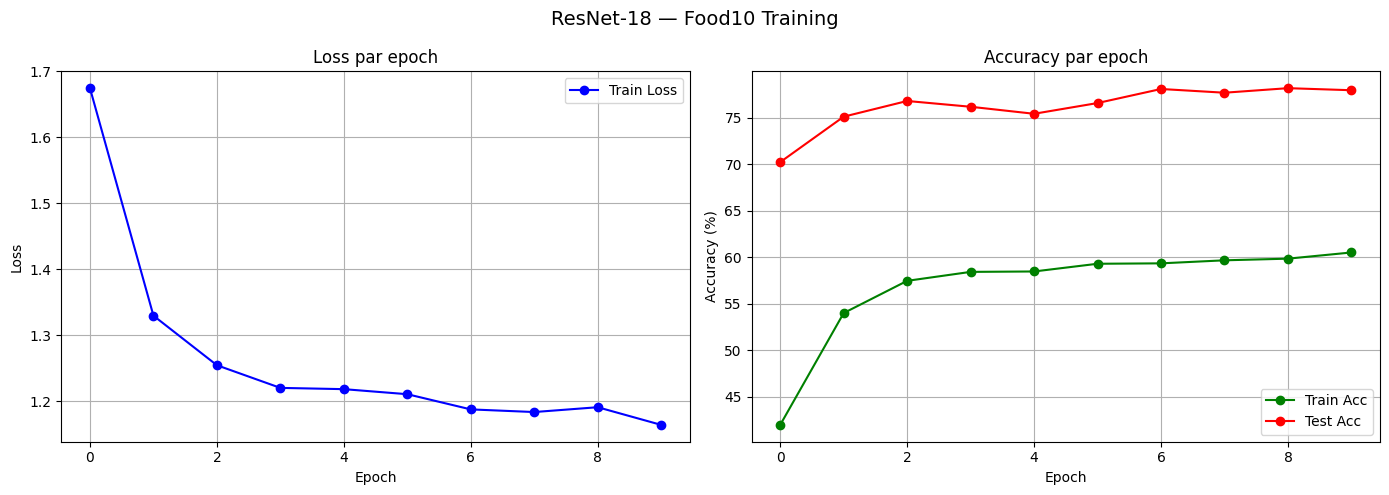

✅ Courbes sauvegardées


In [16]:
# Sauvegarder le modèle
models_dir = Path("C:/SmartMeal/models")
models_dir.mkdir(exist_ok=True)

torch.save({
    "model_state_dict"    : model.state_dict(),
    "selected_classes"    : SELECTED_CLASSES,
    "history"             : history,
    "num_classes"         : len(SELECTED_CLASSES),
}, models_dir / "resnet18_food10.pth")

print(f"✅ Modèle sauvegardé : models/resnet18_food10.pth")

# ── Courbes d'apprentissage ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], "b-o", label="Train Loss")
ax1.set_title("Loss par epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(history["train_acc"], "g-o", label="Train Acc")
ax2.plot(history["test_acc"],  "r-o", label="Test Acc")
ax2.set_title("Accuracy par epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("ResNet-18 — Food10 Training", fontsize=14)
plt.tight_layout()
plt.savefig("C:/SmartMeal/reports/resnet18_training.png", dpi=150)
plt.show()
print("✅ Courbes sauvegardées")